## Methodology

### Training and Snapshot Collection

A ResNet-20 (~272k parameters) is trained on 15,000 CIFAR-10 samples using SGD ($\eta=0.1$, $\mu=0.9$, weight decay $5\times10^{-4}$, batch size 128, 15 epochs, no learning-rate schedule). After every second mini-batch update, three quantities are stored: the full parameter vector $\theta_t$ (iterate), the raw mini-batch gradient $g_t$ (before `optimizer.step()`), and the step vector $\Delta\theta_t = \theta_t - \theta_{t-1}$. This yields $T = 879$ logged snapshots with corresponding gradient and step matrices.

### Phase-wise PCA on Three Spaces

The trajectory is partitioned into $N=8$ equally sized, non-overlapping phases. For each phase, PCA via full SVD is applied independently to three centred matrices: the iterate sub-matrix, the step-vector sub-matrix, and the gradient sub-matrix. The following per-phase metrics are extracted:

- **PC1 share of iterates** ($\downarrow$ from 69\% to 53\% across phases): quantifies how directional the cumulative position trajectory is within each phase.
- **PC1 share of steps** ($\approx$ constant $\sim$5\% after phase 1): the step vectors are far more isotropically distributed than the iterates, confirming that individual SGD updates have no dominant direction.
- **Number of PCs for 90\% variance of steps** ($\downarrow$ from 36 to 34): weakly decreasing, consistent with slight spectral concentration in later phases.

### Subspace Overlap Analysis

Two subspace overlap metrics are computed per phase, following the Gur-Ari style normalised Frobenius overlap between projection matrices:

$$\mathrm{overlap}(V_1, V_2) = \frac{\|Q_1^\top Q_2\|_F^2}{k_1}$$

where $Q_1, Q_2$ are orthonormal bases for the respective subspaces and $k_1 \leq k_2$.

**Gradient overlap with iterate space** (top-10 PCs, $\uparrow$ from 0.37 to 0.40): measures what fraction of gradient energy lies in the low-dimensional subspace spanned by the top-10 iterate PCs. The increasing trend suggests that gradients progressively align with the dominant directions of parameter-space motion as training progresses.

**Gradient overlap with step space** (top-30 PCs, $\uparrow$ from 0.76 to 0.85): measures the same for the step-vector subspace. The consistently higher values confirm that the 30-dimensional step subspace captures the gradient direction far better than the 10-dimensional iterate subspace.

**Step–iterate subspace overlap** ($\approx$ 0.90 throughout): the step-vector subspace and the iterate subspace are nearly co-aligned in all phases, indicating that despite their very different spectral shapes, both spaces span essentially the same low-dimensional region of parameter space.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict
import copy

device = torch.device("mps" if torch.backends.mps.is_available() else
                       "cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ====================== HYPERPARAMETER (frei anpassbar) ======================
SEED = 42

# Daten
TRAIN_SIZE = 15000      # Anzahl Trainingsbeispiele (Subset von CIFAR10, max 50000)
TEST_SIZE = 5000       # Anzahl Testbeispiele (Subset, max 10000)
BATCH_SIZE = 128

# Training
N_EPOCHS = 15
LR = 0.1
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4
USE_LR_SCHEDULE = False          # Cosine-Annealing an/aus

# Trajektorien-Logging
LOG_EVERY_N_STEPS = 2          # alle wie viele Steps wird ein Iterate gespeichert
N_PHASES = 8                    # Anzahl Phasen, in die die Trajektorie unterteilt wird

# PCA
N_PCS_PLOT = 5                  # Anzahl PCs für die Spektrum-Plots
N_PCS_ITERATES = 10             # Anzahl PCs für Iterates-PCA (für Overlap-Analysen)
N_PCS_STEPS = 30                # Anzahl PCs für Schritt-PCA (für Overlap-Analysen)
VARIANCE_THRESHOLD = 0.90       # Schwelle für "wie viele PCs für 90% erkl. Varianz"

torch.manual_seed(SEED)
np.random.seed(SEED)

Device: mps


In [2]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

full_trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
full_testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

# Subset ziehen
train_indices = np.random.choice(len(full_trainset), size=min(TRAIN_SIZE, len(full_trainset)), replace=False)
test_indices = np.random.choice(len(full_testset), size=min(TEST_SIZE, len(full_testset)), replace=False)

trainset = torch.utils.data.Subset(full_trainset, train_indices)
testset = torch.utils.data.Subset(full_testset, test_indices)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train samples: {len(trainset)}, Test samples: {len(testset)}")
print(f"Steps pro Epoch: {len(trainloader)}")

Files already downloaded and verified
Files already downloaded and verified
Train samples: 15000, Test samples: 5000
Steps pro Epoch: 117


In [3]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes)
            )

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return torch.relu(out)


class ResNet20(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.in_planes = 16
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.layer1 = self._make_layer(16, 3, stride=1)
        self.layer2 = self._make_layer(32, 3, stride=2)
        self.layer3 = self._make_layer(64, 3, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(64, num_classes)

    def _make_layer(self, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(BasicBlock(self.in_planes, planes, s))
            self.in_planes = planes * BasicBlock.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        return self.fc(out)


model = ResNet20().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"ResNet20 Parameter: {n_params}")

ResNet20 Parameter: 272474


In [4]:
def get_flat_params(model):
    """Alle Parameter als ein flacher Vektor."""
    return torch.cat([p.data.view(-1) for p in model.parameters()]).cpu().numpy()

def get_flat_grad(model):
    """Alle Gradienten als ein flacher Vektor (für den 'Gradienten'-Proxy)."""
    grads = []
    for p in model.parameters():
        if p.grad is not None:
            grads.append(p.grad.view(-1))
        else:
            grads.append(torch.zeros_like(p).view(-1))
    return torch.cat(grads).cpu().numpy()

In [5]:
model = ResNet20().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)

total_steps = N_EPOCHS * len(trainloader)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps) if USE_LR_SCHEDULE else None

iterates = []       # theta_t  (Parameter-Snapshots)
true_gradients = []  # echte p.grad direkt nach backward()
step_vectors = []    # Delta theta_t = theta_t - theta_{t-1}

prev_params = get_flat_params(model).copy()
iterates.append(prev_params.copy())

step_count = 0
model.train()

for epoch in range(N_EPOCHS):
    running_loss = 0.0
    for batch_idx, (inputs, targets) in enumerate(trainloader):
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()

        if step_count % LOG_EVERY_N_STEPS == 0:
            true_gradients.append(get_flat_grad(model).copy())

        optimizer.step()
        if scheduler is not None:
            scheduler.step()

        if step_count % LOG_EVERY_N_STEPS == 0:
            cur_params = get_flat_params(model)
            iterates.append(cur_params.copy())
            step_vectors.append(cur_params - prev_params)
            prev_params = cur_params.copy()

        running_loss += loss.item()
        step_count += 1

    print(f"Epoch {epoch+1}/{N_EPOCHS}  Loss: {running_loss/len(trainloader):.4f}  "
          f"LR: {optimizer.param_groups[0]['lr']:.5f}")

iterates = np.array(iterates)              # shape: (T+1, P)
true_gradients = np.array(true_gradients)  # shape: (T, P)
step_vectors = np.array(step_vectors)      # shape: (T, P)

print(f"\nIterates shape: {iterates.shape}")
print(f"Echte Gradienten shape: {true_gradients.shape}")
print(f"Schrittvektoren shape: {step_vectors.shape}")

Epoch 1/15  Loss: 1.9242  LR: 0.10000
Epoch 2/15  Loss: 1.6726  LR: 0.10000
Epoch 3/15  Loss: 1.4634  LR: 0.10000
Epoch 4/15  Loss: 1.3116  LR: 0.10000
Epoch 5/15  Loss: 1.2104  LR: 0.10000
Epoch 6/15  Loss: 1.0794  LR: 0.10000
Epoch 7/15  Loss: 1.0171  LR: 0.10000
Epoch 8/15  Loss: 0.9646  LR: 0.10000
Epoch 9/15  Loss: 0.9048  LR: 0.10000
Epoch 10/15  Loss: 0.8529  LR: 0.10000
Epoch 11/15  Loss: 0.8031  LR: 0.10000
Epoch 12/15  Loss: 0.7627  LR: 0.10000
Epoch 13/15  Loss: 0.7466  LR: 0.10000
Epoch 14/15  Loss: 0.7199  LR: 0.10000
Epoch 15/15  Loss: 0.6854  LR: 0.10000

Iterates shape: (879, 272474)
Echte Gradienten shape: (878, 272474)
Schrittvektoren shape: (878, 272474)


In [6]:
def split_into_phases(array, n_phases):
    """Teilt array entlang der Zeitachse (axis=0) in n_phases gleich große Stücke."""
    T = array.shape[0]
    boundaries = np.linspace(0, T, n_phases + 1).astype(int)
    phases = []
    for i in range(n_phases):
        phases.append(array[boundaries[i]:boundaries[i+1]])
    return phases, boundaries

# Iterates: wir nehmen Schrittvektoren-Länge T für die Konsistenz der Phasengrenzen
# (iterates hat T+1 Einträge, step_vectors/true_gradients haben T)
iterate_phases, phase_boundaries = split_into_phases(iterates[1:], N_PHASES)  # iterates ab Index 1, synchron zu Schritten
step_phases, _ = split_into_phases(step_vectors, N_PHASES)
grad_phases, _ = split_into_phases(true_gradients, N_PHASES)

print(f"Phasengrenzen (in geloggten Steps): {phase_boundaries}")
for i, p in enumerate(step_phases):
    print(f"Phase {i+1}: {p.shape[0]} Schritte")

Phasengrenzen (in geloggten Steps): [  0 109 219 329 439 548 658 768 878]
Phase 1: 109 Schritte
Phase 2: 110 Schritte
Phase 3: 110 Schritte
Phase 4: 110 Schritte
Phase 5: 109 Schritte
Phase 6: 110 Schritte
Phase 7: 110 Schritte
Phase 8: 110 Schritte


In [7]:
from numpy.linalg import svd

def pca_fit(X, n_components=None):
    """
    PCA via SVD auf zentrierten Daten X (n_samples, n_features).
    Gibt zurück: components (n_components, n_features), explained_var_ratio, mean
    """
    mean = X.mean(axis=0)
    Xc = X - mean
    n_samples = Xc.shape[0]

    # SVD im sample-space wenn n_features >> n_samples (effizienter)
    if n_components is None:
        n_components = min(Xc.shape) 

    U, S, Vt = svd(Xc, full_matrices=False)
    explained_var = (S ** 2) / (n_samples - 1)
    total_var = explained_var.sum()
    explained_var_ratio = explained_var / total_var

    components = Vt[:n_components]  # (n_components, n_features)
    return components, explained_var_ratio[:n_components], mean

In [10]:
def subspace_overlap(V1, V2):
    """
    Overlap zwischen zwei Unterräumen, aufgespannt durch die Zeilen von V1 (k1, P) und V2 (k2, P).
    Gur-Ari-Style Metrik: normalisierter Frobenius-Norm-Overlap der Projektionsmatrizen.
    Liegt zwischen 0 (orthogonal) und 1 (identischer Raum, bei k1<=k2).
    """
    # Orthonormalisieren (SVD-Komponenten sind bereits orthonormal, aber zur Sicherheit)
    Q1, _ = np.linalg.qr(V1.T)  # (P, k1)
    Q2, _ = np.linalg.qr(V2.T)  # (P, k2)

    k1 = Q1.shape[1]
    overlap_matrix = Q1.T @ Q2  # (k1, k2)
    overlap = np.linalg.norm(overlap_matrix, 'fro') ** 2 / k1
    return overlap

def vector_subspace_overlap(vectors, V):
    """
    Overlap zwischen einer Menge von Vektoren (n_samples, P) und einem PCA-Unterraum V (k, P).
    Misst pro Vektor den Anteil seiner Norm, der im Unterraum liegt, gemittelt.
    Analog zu Gur-Ari's Gradient-Subspace-Overlap.
    """
    Q, _ = np.linalg.qr(V.T)  # (P, k) orthonormal
    proj = vectors @ Q  # (n_samples, k)
    proj_norm_sq = np.sum(proj ** 2, axis=1)
    full_norm_sq = np.sum(vectors ** 2, axis=1)
    ratio = proj_norm_sq / (full_norm_sq + 1e-12)
    return ratio.mean(), ratio.std()

In [11]:
iterate_pca_fixed = []  # Liste von (components, var_ratio, mean), N_PCS_ITERATES Komponenten
step_pca_fixed = []     # Liste von (components, var_ratio, mean), N_PCS_STEPS Komponenten

for i in range(N_PHASES):
    comp_it, var_it, mean_it = pca_fit(iterate_phases[i], n_components=N_PCS_ITERATES)
    iterate_pca_fixed.append((comp_it, var_it, mean_it))

    comp_st, var_st, mean_st = pca_fit(step_phases[i], n_components=N_PCS_STEPS)
    step_pca_fixed.append((comp_st, var_st, mean_st))

print(f"Iterates-PCA: {N_PCS_ITERATES} Komponenten pro Phase")
print(f"Schritt-PCA: {N_PCS_STEPS} Komponenten pro Phase")

Iterates-PCA: 10 Komponenten pro Phase
Schritt-PCA: 30 Komponenten pro Phase


In [18]:
# ============================================================
#  Gradient-Overlap mit PCA-Unterräumen
# ============================================================
import matplotlib.pyplot as plt

LBL, TTL, TCK = 16, 18, 14   # label / title / tick fontsize

# ============================================================================
# WICHTIG: Hier wird als "Gradient" der SCHRITTVEKTOR (step_vectors) verwendet,
# NICHT der echte p.grad-Gradient aus Zelle 5 (true_gradients).
# Methodisch sind das SGD-Updates (inkl. Momentum, LR, Weight Decay), keine
# reinen Verlust-Gradienten. Falls du stattdessen die echten Gradienten
# (true_gradients) verwenden willst, ersetze unten grad_phases_used.
# ============================================================================

grad_phases_used = step_phases  # <- "Gradient" = Schrittvektor (wie gewünscht)

print("=== 'Gradient' overlap with iterates-PCA space (top-10) ===\n")
grad_iterate_overlap = []
for i in range(N_PHASES):
    V_it = iterate_pca_fixed[i][0]
    mean_ratio, std_ratio = vector_subspace_overlap(grad_phases_used[i], V_it)
    grad_iterate_overlap.append(mean_ratio)
    print(f"Phase {i+1}: mean overlap = {mean_ratio:.3f}  (std = {std_ratio:.3f})")

print("\n=== 'Gradient' overlap with step-PCA space (top-30) ===\n")
grad_step_overlap = []
for i in range(N_PHASES):
    V_st = step_pca_fixed[i][0]
    mean_ratio, std_ratio = vector_subspace_overlap(grad_phases_used[i], V_st)
    grad_step_overlap.append(mean_ratio)
    print(f"Phase {i+1}: mean overlap = {mean_ratio:.3f}  (std = {std_ratio:.3f})")


def plot_gradient_overlap(show_title=True):
    fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
    ax.set_facecolor('white')

    x = range(1, N_PHASES + 1)
    ax.plot(x, grad_iterate_overlap, marker='o', lw=2.4, ms=9,
            label="'Gradient' <-> iterates-PCA space (10 PCs)")
    ax.plot(x, grad_step_overlap, marker='s', lw=2.4, ms=9,
            label="'Gradient' <-> step-PCA space (30 PCs)")

    ax.set_xlabel("Phase", fontsize=LBL)
    ax.set_ylabel("Mean overlap ratio", fontsize=LBL)
    ax.tick_params(axis='both', labelsize=TCK)
    ax.set_ylim(0, 1.05)

    if show_title:
        ax.set_title("Gur-Ari-style: gradient concentration in PCA top subspace",
                     fontsize=TTL)

    ax.legend(fontsize=TCK - 2)
    plt.tight_layout()
    plt.show()

=== 'Gradient' overlap with iterates-PCA space (top-10) ===

Phase 1: mean overlap = 0.371  (std = 0.127)
Phase 2: mean overlap = 0.328  (std = 0.091)
Phase 3: mean overlap = 0.344  (std = 0.094)
Phase 4: mean overlap = 0.352  (std = 0.078)
Phase 5: mean overlap = 0.366  (std = 0.086)
Phase 6: mean overlap = 0.383  (std = 0.091)
Phase 7: mean overlap = 0.393  (std = 0.088)
Phase 8: mean overlap = 0.400  (std = 0.096)

=== 'Gradient' overlap with step-PCA space (top-30) ===

Phase 1: mean overlap = 0.763  (std = 0.111)
Phase 2: mean overlap = 0.804  (std = 0.048)
Phase 3: mean overlap = 0.821  (std = 0.048)
Phase 4: mean overlap = 0.828  (std = 0.040)
Phase 5: mean overlap = 0.846  (std = 0.032)
Phase 6: mean overlap = 0.845  (std = 0.033)
Phase 7: mean overlap = 0.854  (std = 0.026)
Phase 8: mean overlap = 0.854  (std = 0.026)


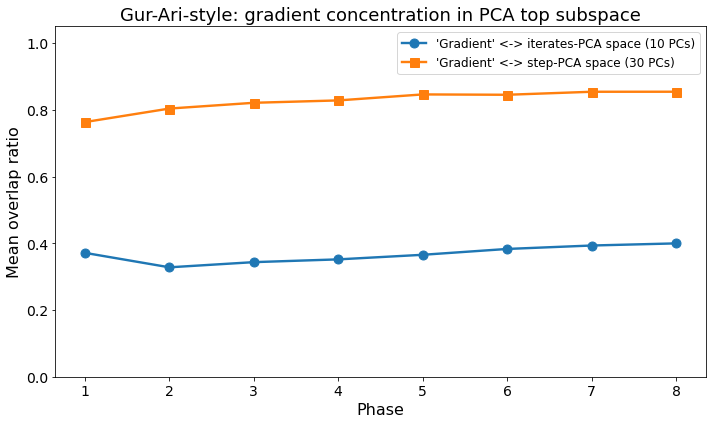

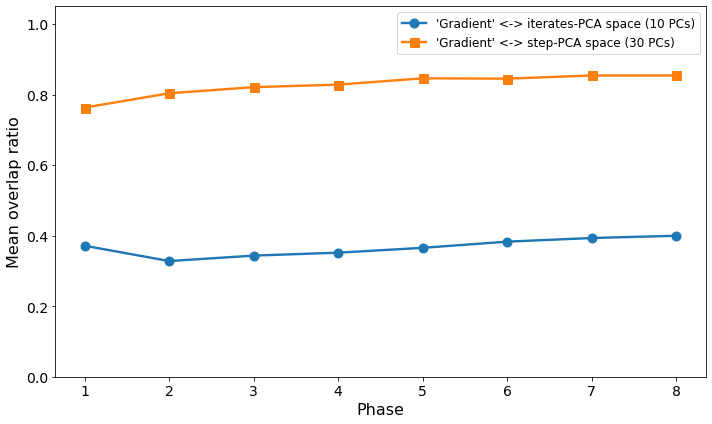

In [19]:
plot_gradient_overlap(show_title=True)
plot_gradient_overlap(show_title=False)

=== Overlap zwischen Schritt-PCA-Raum (30) und Iterates-PCA-Raum (10) ===

Phase 1: Overlap(Iterates-Raum, Schritt-Raum) = 0.897
Phase 2: Overlap(Iterates-Raum, Schritt-Raum) = 0.902
Phase 3: Overlap(Iterates-Raum, Schritt-Raum) = 0.903
Phase 4: Overlap(Iterates-Raum, Schritt-Raum) = 0.902
Phase 5: Overlap(Iterates-Raum, Schritt-Raum) = 0.905
Phase 6: Overlap(Iterates-Raum, Schritt-Raum) = 0.905
Phase 7: Overlap(Iterates-Raum, Schritt-Raum) = 0.907
Phase 8: Overlap(Iterates-Raum, Schritt-Raum) = 0.907


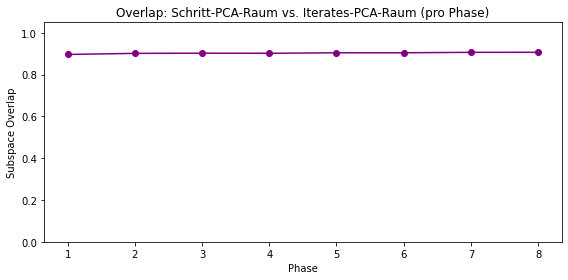

In [14]:
print("=== Overlap zwischen Schritt-PCA-Raum (30) und Iterates-PCA-Raum (10) ===\n")

step_iterate_space_overlap = []
for i in range(N_PHASES):
    V_st = step_pca_fixed[i][0]
    V_it = iterate_pca_fixed[i][0]
    # kleinerer Raum (Iterates, k=10) zuerst -> normiert auf k1=10
    ov = subspace_overlap(V_it, V_st)
    step_iterate_space_overlap.append(ov)
    print(f"Phase {i+1}: Overlap(Iterates-Raum, Schritt-Raum) = {ov:.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, N_PHASES + 1), step_iterate_space_overlap, marker='o', color='purple')
ax.set_xlabel("Phase")
ax.set_ylabel("Subspace Overlap")
ax.set_title("Overlap: Schritt-PCA-Raum vs. Iterates-PCA-Raum (pro Phase)")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [15]:
import pandas as pd

summary = pd.DataFrame({
    "Phase": range(1, N_PHASES + 1),
    "PC1_var_iterates": pc1_iterates,
    "PC1_var_steps": pc1_steps,
    "n_PCs_90pct_steps": n_pcs_for_threshold,
    "grad_overlap_iterate_space": grad_iterate_overlap,
    "grad_overlap_step_space": grad_step_overlap,
    "step_iterate_space_overlap": step_iterate_space_overlap,
})

print(summary.to_string(index=False))
summary

 Phase  PC1_var_iterates  PC1_var_steps  n_PCs_90pct_steps  grad_overlap_iterate_space  grad_overlap_step_space  step_iterate_space_overlap
     1          0.691226       0.152380                 36                    0.371365                 0.763356                    0.896558
     2          0.725739       0.046626                 36                    0.328072                 0.803836                    0.901804
     3          0.647100       0.046696                 35                    0.343589                 0.821089                    0.902637
     4          0.598787       0.048651                 35                    0.351880                 0.828225                    0.902215
     5          0.576628       0.048346                 34                    0.365606                 0.846162                    0.904664
     6          0.549501       0.049890                 34                    0.383113                 0.845125                    0.904695
     7          0.53

,Phase,PC1_var_iterates,PC1_var_steps,n_PCs_90pct_steps,grad_overlap_iterate_space,grad_overlap_step_space,step_iterate_space_overlap
0,1,0.691226,0.152380,36,0.371365,0.763356,0.896558
1,2,0.725739,0.046626,36,0.328072,0.803836,0.901804
2,3,0.647100,0.046696,35,0.343589,0.821089,0.902637
3,4,0.598787,0.048651,35,0.351880,0.828225,0.902215
4,5,0.576628,0.048346,34,0.365606,0.846162,0.904664
5,6,0.549501,0.049890,34,0.383113,0.845125,0.904695
6,7,0.538863,0.051270,34,0.393403,0.854137,0.906690
7,8,0.525038,0.051768,34,0.399784,0.854253,0.906939
